# Notebook for finding the parameters where recall is 1 and runtime is good

In [40]:
import os
import sys
import itertools


def find_project_root(target_folder="masteroppgave"):
    """Find the absolute path of a folder by searching upward."""
    currentdir = os.path.abspath("__file__")  # Get absolute script path
    while True:
        if os.path.basename(currentdir) == target_folder:
            return currentdir  # Found the target folder
        parentdir = os.path.dirname(currentdir)
        if parentdir == currentdir:  # Stop at filesystem root
            return None
        currentdir = parentdir  # Move one level up

# Example usage
project_root = find_project_root("masteroppgave")

if project_root:
    sys.path.append(project_root)
    print(f"Project root found: {project_root}")
else:
    raise RuntimeError("Could not find 'masteroppgave' directory")

from utils.helpers.measure_similarities import *

Project root found: /cluster/home/eivindoy/masteroppgave


In [41]:
CITY = "rome"
MEASURE = "dtw"
DATA_SIZE = [500]
SCHEME = "disk"
BUCKETING_METHOD = "loose"

## Read Bucketing Runtime CSV

In [42]:

folder_path = f"../../results_hashed/runtimes/bucketing/{CITY}/true_trajectories/{BUCKETING_METHOD}/{MEASURE}/"
file_name = f"runtimes_bucketing({BUCKETING_METHOD})_(true_trajectories)_{CITY}_{MEASURE}_{DATA_SIZE}_{SCHEME}.csv"
file_path = folder_path + file_name
runtime_bucketing = pd.read_csv(file_path, index_col=0)
runtime_bucketing.head()

,Measure,Diameter,Layers,Disks,Size,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Average Bucket Distribution Time (Seconds),Total time (Seconds)
City,,,,,,,,,
rome,dtw,0.6,3,40,500,42.633,1.292,0.158,44.083
rome,dtw,0.6,3,50,500,47.587,1.322,0.201,49.110
rome,dtw,0.6,4,40,500,47.902,1.815,0.213,49.930
rome,dtw,0.6,4,50,500,49.505,1.745,0.260,51.510
rome,dtw,0.6,5,40,500,50.499,2.143,0.265,52.907


## Read No Bucketing Runtime CSV

In [43]:

folder_path = f"../../results_hashed/runtimes/no_bucketing/{CITY}/{MEASURE}/"
file_name = f"runtimes_{CITY}_{MEASURE}_{DATA_SIZE}_{SCHEME}_no_bucketing.csv"
file_path = folder_path + file_name
runtime_no_bucketing = pd.read_csv(file_path)
runtime_no_bucketing.head(5)

,City,Measure,Diameter,Layers,Disks,Size,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Total time (Seconds)
0,rome,dtw,0.2,3,40,500,0.565,1.164,1.729
1,rome,dtw,0.4,3,40,500,0.981,1.175,2.156
2,rome,dtw,0.6,3,40,500,1.384,1.197,2.581
3,rome,dtw,0.8,3,40,500,1.772,1.214,2.986
4,rome,dtw,1.0,3,40,500,2.051,1.226,3.277


## Read No Bucketing Correlation

In [44]:
DATA_SIZE_WITHOUT_BRACKETS = DATA_SIZE[0]
folder_path = f"../correlation/no_bucketing_correlation_values/"
file_name = f"correlation_results_{CITY}_disk_no_bucketing_{DATA_SIZE_WITHOUT_BRACKETS}.csv"
file_path = folder_path + file_name
correlation_no_bucketing = pd.read_csv(file_path, index_col=0)
correlation_no_bucketing.head(5)

#Merge runtime_no_bucketing and correlation_no_bucketing on columns "Diameter" and "Layers"
runtime_no_bucketing = pd.merge(runtime_no_bucketing, correlation_no_bucketing, on=["Diameter", "Layers"])
runtime_no_bucketing.head(5)


,City,Measure,Diameter,Layers,Disks,Size,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Total time (Seconds),Correlation
0,rome,dtw,0.2,3,40,500,0.565,1.164,1.729,0.162
1,rome,dtw,0.4,3,40,500,0.981,1.175,2.156,0.285
2,rome,dtw,0.6,3,40,500,1.384,1.197,2.581,0.400
3,rome,dtw,0.8,3,40,500,1.772,1.214,2.986,0.425
4,rome,dtw,1.0,3,40,500,2.051,1.226,3.277,0.464


## Read Bucket Evaluation CSV

In [45]:
folder_path = f"../../results_hashed/bucket_evaluation/{BUCKETING_METHOD}/"
file_name = f"{CITY}_{MEASURE}_{SCHEME}_{DATA_SIZE_WITHOUT_BRACKETS}_{BUCKETING_METHOD}.csv"
file_path = folder_path + file_name

bucket_evaluation = pd.read_csv(file_path, index_col=0)

bucket_evaluation.head(5)

,Measure,Diameter,Layers,Disks,Size,Threshold,Avg Precision,Avg Recall,Avg F1 Score,Avg Number of buckets,Avg Bucket size,Avg Buckets with >1 Trajectory,Avg Largest Bucket Size,Avg Correlation Coefficient
City,,,,,,,,,,,,,,
rome,dtw,0.6,1,10,500,0.1,0.003,0.844,0.006,9.208,25.239,8.833,78.167,1.0
rome,dtw,0.6,1,10,500,0.2,0.017,0.725,0.034,9.208,25.239,8.833,78.167,1.0
rome,dtw,0.6,1,10,500,0.3,0.046,0.641,0.084,9.208,25.239,8.833,78.167,1.0
rome,dtw,0.6,1,10,500,0.4,0.079,0.558,0.136,9.208,25.239,8.833,78.167,1.0
rome,dtw,0.6,1,10,500,0.5,0.119,0.491,0.187,9.208,25.239,8.833,78.167,1.0


In [46]:
# First, filter the bucket_evaluation dataframe
filtered_eval = bucket_evaluation[
    (bucket_evaluation["Avg Recall"] == 1) &
    (bucket_evaluation["Threshold"] == 0.1)
]

# Select only the necessary columns from runtime_bucketing
runtime_selected = runtime_bucketing[[
    "Diameter", "Layers",
    "Average Similarity Computation Time (Seconds)",
    "Average Hash Generation Time (Seconds)",
    "Average Bucket Distribution Time (Seconds)",
    "Total time (Seconds)"
]]

# Merge using only Diameter, Layers, and Disks as keys
runtime_bucketing_and_bucket_evaluation = filtered_eval.merge(
    runtime_selected,
    on=["Diameter", "Layers"],
    how="left"
)



runtime_bucketing_and_bucket_evaluation.head(5)



,Measure,Diameter,Layers,Disks,Size,Threshold,Avg Precision,Avg Recall,Avg F1 Score,Avg Number of buckets,Avg Bucket size,Avg Buckets with >1 Trajectory,Avg Largest Bucket Size,Avg Correlation Coefficient,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Average Bucket Distribution Time (Seconds),Total time (Seconds)
0,dtw,0.6,3,40,500,0.1,0.001,1.0,0.002,113.792,26.118,110.417,143.625,1.0,42.633,1.292,0.158,44.083
1,dtw,0.6,3,40,500,0.1,0.001,1.0,0.002,113.792,26.118,110.417,143.625,1.0,47.587,1.322,0.201,49.110
2,dtw,0.6,3,50,500,0.1,0.001,1.0,0.002,140.917,26.989,136.875,150.792,1.0,42.633,1.292,0.158,44.083
3,dtw,0.6,3,50,500,0.1,0.001,1.0,0.002,140.917,26.989,136.875,150.792,1.0,47.587,1.322,0.201,49.110
4,dtw,0.6,4,40,500,0.1,0.001,1.0,0.002,150.000,26.679,144.667,146.375,1.0,47.902,1.815,0.213,49.930


In [47]:
# Sort the merged dataframe by Avg Correlation Coefficient in descending order
runtime_bucketing_and_bucket_evaluation_sorted = runtime_bucketing_and_bucket_evaluation.sort_values(
    by="Total time (Seconds)",
    ascending=True
)

#extract lowest runtime Total time (Seconds) in the runtime_bucketing_and_bucket_evaluation_sorted dataframe
lowest_runtime = runtime_bucketing_and_bucket_evaluation_sorted.iloc[0]

lowest_runtime = runtime_bucketing_and_bucket_evaluation_sorted["Total time (Seconds)"].min()

print(lowest_runtime)

runtime_bucketing_and_bucket_evaluation_sorted.head(5)



44.083


,Measure,Diameter,Layers,Disks,Size,Threshold,Avg Precision,Avg Recall,Avg F1 Score,Avg Number of buckets,Avg Bucket size,Avg Buckets with >1 Trajectory,Avg Largest Bucket Size,Avg Correlation Coefficient,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Average Bucket Distribution Time (Seconds),Total time (Seconds)
0,dtw,0.6,3,40,500,0.1,0.001,1.0,0.002,113.792,26.118,110.417,143.625,1.0,42.633,1.292,0.158,44.083
2,dtw,0.6,3,50,500,0.1,0.001,1.0,0.002,140.917,26.989,136.875,150.792,1.0,42.633,1.292,0.158,44.083
1,dtw,0.6,3,40,500,0.1,0.001,1.0,0.002,113.792,26.118,110.417,143.625,1.0,47.587,1.322,0.201,49.110
3,dtw,0.6,3,50,500,0.1,0.001,1.0,0.002,140.917,26.989,136.875,150.792,1.0,47.587,1.322,0.201,49.110
4,dtw,0.6,4,40,500,0.1,0.001,1.0,0.002,150.000,26.679,144.667,146.375,1.0,47.902,1.815,0.213,49.930


In [50]:
# print(runtime_no_bucketing.head(5))


# # Merge runtime_no_bucketing with merged_df_sorted top 5 rows
# runtime_no_bucketing_vs_runtime_bucketing = runtime_bucketing_and_bucket_evaluation_sorted.head(5)
# runtime_no_bucketing_vs_runtime_bucketing = runtime_no_bucketing_vs_runtime_bucketing.merge(
#     runtime_no_bucketing,
#     on=["Diameter", "Layers"],
#     how="left",
#     suffixes=("", "_no_bucketing")
# )
# # Rename the columns to avoid confusion
# runtime_no_bucketing_vs_runtime_bucketing.rename(
#     columns={
#         "Average Similarity Computation Time (Seconds)": "Average Similarity Computation Time (Seconds)_bucketing",
#         "Average Hash Generation Time (Seconds)": "Average Hash Generation Time (Seconds)_bucketing",
#         "Average Bucket Distribution Time (Seconds)": "Average Bucket Distribution Time (Seconds)_bucketing",
#         "Total time (Seconds)": "Total time (Seconds)_bucketing"
#     },
#     inplace=True
# )




# runtime_no_bucketing_vs_runtime_bucketing.head()


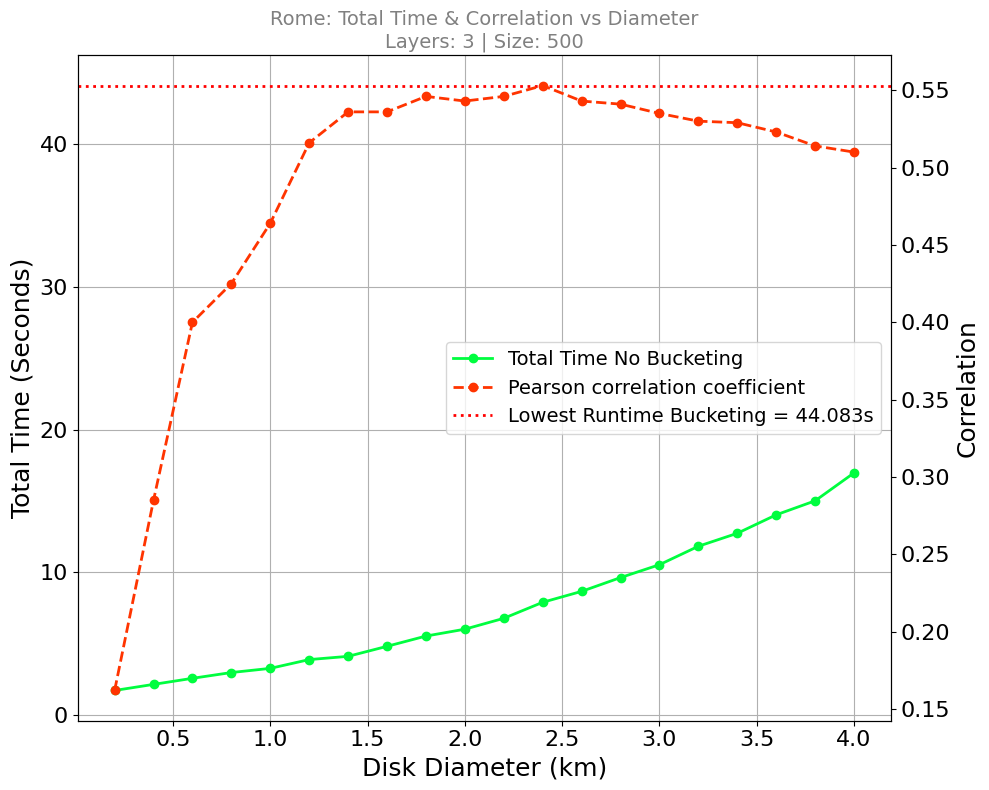

In [54]:
# Filter the runtime_no_bucketing dataframe to only include the rows where Layers = 3
filtered_runtime_no_bucketing = runtime_no_bucketing[runtime_no_bucketing["Layers"] == 3]

# print(filtered_runtime_no_bucketing[["Resolution", "Correlation"]])


import matplotlib.pyplot as plt
import numpy as np

def plot_total_time_vs_diameter(
    df,
    city: str,
    measure: str = "dtw",
    layers: int = 3,
    size: int = 500,
    lowest_runtime: float = None,  # Add this argument
):
    """
    Plots the relationship between diameter and total time (in seconds),
    and overlays correlation on a secondary y-axis with clear labels.
    Adds a horizontal line for the externally provided lowest total runtime.
    """

    # Filter the DataFrame
    filtered = df[
        (df['City'] == city) &
        (df['Measure'] == measure) &
        (df['Layers'] == layers) &
        (df['Size'] == size)
    ].sort_values(by='Diameter')

    # Extract values
    res = filtered['Diameter'].values
    total_time = filtered['Total time (Seconds)'].values
    corr = filtered['Correlation'].astype(float).values

    # Plot
    fig, ax1 = plt.subplots(figsize=(10, 8), dpi=100)
    ax2 = ax1.twinx()
    cmap = plt.get_cmap("gist_ncar")

    line1 = ax1.plot(res, total_time, color=cmap(0.3), marker='o', lw=2, label='Total Time No Bucketing')[0]
    line2 = ax2.plot(res, corr, color=cmap(0.7), marker='o', lw=2, linestyle='--', label='Pearson correlation coefficient')[0]

    # Use provided lowest_runtime if available
    if lowest_runtime is not None:
        line3 = ax1.axhline(
            y=lowest_runtime,
            color='red',
            linestyle=':',
            linewidth=2,
            label=f'Lowest Runtime Bucketing = {lowest_runtime:.3f}s'
        )
        lines = [line1, line2, line3]
    else:
        lines = [line1, line2]

    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="center right", fontsize=14)

    # Axis labels and styling
    ax1.set_xlabel("Disk Diameter (km)", fontsize=18)
    ax1.set_ylabel("Total Time (Seconds)", fontsize=18)
    ax2.set_ylabel("Correlation", fontsize=18)
    

    ax1.tick_params(axis="both", which="major", labelsize=16)
    ax2.tick_params(axis="both", which="major", labelsize=16)

    ax1.set_title(
        f"{city.capitalize()}: Total Time & Correlation vs Diameter\nLayers: {layers} | Size: {size}",
        fontsize=14,
        color='grey'
    )

    ax1.grid(True)
    fig.tight_layout()
    plt.show()




plot_total_time_vs_diameter(
    filtered_runtime_no_bucketing,
    city=CITY,
    measure="dtw",
    layers=3,
    size=500,
    lowest_runtime=lowest_runtime  # Pass the value from your earlier cell
)


# filtered_runtime_no_bucketing.head(5)
